## Business Understanding (Hotel Booking Cancellation)

### What is the business about?
The business is a hotel booking platform that manages reservations for different types of hotels. It collects booking information from customers and processes reservations through various channels and market segments.



### What problem is the business trying to solve?
The business is trying to reduce **booking cancellations**. Last-minute cancellations lead to revenue loss, inefficient room allocation, and operational uncertainty. The goal is to predict whether a booking will be cancelled in advance.



### What decision can machine learning help the business make?
Machine learning can help the hotel **predict whether a customer is likely to cancel a booking before arrival**. This allows the hotel to:

- Adjust room availability planning
- Overbook strategically when needed
- Target customers with reminders or offers
- Reduce revenue loss from cancellations



### What is the target variable in the dataset?
The target variable is:

**Booking_Cancelled**

This indicates whether a hotel booking was cancelled (1) or not cancelled (0).



### What are the input features?
The input features include all variables used to predict cancellation, such as:

- Booking_Date  
- Hotel_Type  
- Arrival_Month  
- Booking_Channel  
- Market_Segment  
- Customer_Type  
- Reserved_Room_Type  
- Meal_Plan  
- Deposit_Type  
- Lead_Time_Days  
- Weekend_Nights  
- Weekday_Nights  
- Adults  
- Children  
- Previous_Cancellations  
- Repeated_Guest  
- Special_Requests  
- Average_Daily_Rate  
- Parking_Requested  
- Loyalty_Points  



### Why is this prediction useful for the business?
This prediction is useful because it helps the hotel **anticipate booking cancellations before they happen**, which improves operational efficiency and revenue management. It allows the hotel to make better decisions on room allocation, pricing strategies, and customer engagement. It also reduces uncertainty in demand forecasting and improves overall customer service planning.

In [1]:
import pandas as pd 

In [3]:
df = pd.read_excel("stayease_hotel_booking_cancellation_dataset.xlsx")

In [5]:
df.head()

,Booking_ID,Booking_Date,Hotel_Type,Arrival_Month,Booking_Channel,Market_Segment,Customer_Type,Reserved_Room_Type,Meal_Plan,Deposit_Type,...,Weekday_Nights,Adults,Children,Previous_Cancellations,Repeated_Guest,Special_Requests,Average_Daily_Rate,Parking_Requested,Loyalty_Points,Booking_Cancelled
0,BK0001,2026-02-10,Lakeside Resort,December,Direct Website,Family,Loyalty Member,Standard,Room Only,No Deposit,...,2,2,0,0,1,1,218.04,No,1599,0
1,BK0002,2026-02-28,Lakeside Resort,July,Online Travel Agency,Leisure,New Guest,Standard,Room Only,Partial Deposit,...,5,2,0,3,0,1,248.94,Yes,0,1
2,BK0003,2026-02-28,Airport Business Hotel,June,Phone Reservation,Conference,New Guest,Suite,Breakfast Included,No Deposit,...,4,2,0,0,0,0,418.14,No,0,0
3,BK0004,2026-02-05,City Center Boutique,December,Travel Agent,Business,New Guest,Standard,Breakfast Included,Non-refundable,...,2,3,0,0,0,1,180.31,No,0,0
4,BK0005,2026-01-01,Lakeside Resort,November,Online Travel Agency,Family,New Guest,Suite,Room Only,No Deposit,...,7,3,0,0,0,1,306.34,No,43,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Booking_ID              380 non-null    object 
 1   Booking_Date            380 non-null    object 
 2   Hotel_Type              380 non-null    object 
 3   Arrival_Month           380 non-null    object 
 4   Booking_Channel         380 non-null    object 
 5   Market_Segment          380 non-null    object 
 6   Customer_Type           380 non-null    object 
 7   Reserved_Room_Type      380 non-null    object 
 8   Meal_Plan               380 non-null    object 
 9   Deposit_Type            380 non-null    object 
 10  Lead_Time_Days          380 non-null    int64  
 11  Weekend_Nights          380 non-null    int64  
 12  Weekday_Nights          380 non-null    int64  
 13  Adults                  380 non-null    int64  
 14  Children                380 non-null    in

In [9]:
df.shape

(380, 22)

In [11]:
df.isnull().sum()

Booking_ID                0
Booking_Date              0
Hotel_Type                0
Arrival_Month             0
Booking_Channel           0
Market_Segment            0
Customer_Type             0
Reserved_Room_Type        0
Meal_Plan                 0
Deposit_Type              0
Lead_Time_Days            0
Weekend_Nights            0
Weekday_Nights            0
Adults                    0
Children                  0
Previous_Cancellations    0
Repeated_Guest            0
Special_Requests          0
Average_Daily_Rate        0
Parking_Requested         0
Loyalty_Points            0
Booking_Cancelled         0
dtype: int64

In [13]:
df.duplicated().sum()

0

In [15]:
# Features
X = df.drop('Booking_Cancelled', axis=1)

# Target
y = df['Booking_Cancelled']

In [17]:
print(X.shape)
print(y.shape)

print(X.head())
print(y.head())

(380, 21)
(380,)
  Booking_ID Booking_Date              Hotel_Type Arrival_Month  \
0     BK0001   2026-02-10         Lakeside Resort      December   
1     BK0002   2026-02-28         Lakeside Resort          July   
2     BK0003   2026-02-28  Airport Business Hotel          June   
3     BK0004   2026-02-05    City Center Boutique      December   
4     BK0005   2026-01-01         Lakeside Resort      November   

        Booking_Channel Market_Segment   Customer_Type Reserved_Room_Type  \
0        Direct Website         Family  Loyalty Member           Standard   
1  Online Travel Agency        Leisure       New Guest           Standard   
2     Phone Reservation     Conference       New Guest              Suite   
3          Travel Agent       Business       New Guest           Standard   
4  Online Travel Agency         Family       New Guest              Suite   

            Meal_Plan     Deposit_Type  ...  Weekend_Nights  Weekday_Nights  \
0           Room Only       No Deposit

In [19]:
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Booking_ID', 'Booking_Date', 'Hotel_Type', 'Arrival_Month',
       'Booking_Channel', 'Market_Segment', 'Customer_Type',
       'Reserved_Room_Type', 'Meal_Plan', 'Deposit_Type', 'Parking_Requested'],
      dtype='object')


In [21]:
numerical_cols = X.select_dtypes(exclude=['object']).columns
print(numerical_cols)

Index(['Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights', 'Adults',
       'Children', 'Previous_Cancellations', 'Repeated_Guest',
       'Special_Requests', 'Average_Daily_Rate', 'Loyalty_Points'],
      dtype='object')


In [23]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

# Create a one-hot encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", encoder, categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

print("Preprocessor has been created successfully.")

Preprocessor has been created successfully.


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(304, 491)
(76, 491)


In [29]:
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree classification model
decision_tree_model = DecisionTreeClassifier(
# Limit the depth of the tree to make it easier to understand
max_depth=4,
# Use a fixed random state to make the result reproducible
random_state=42
)
# Print a message to confirm that the model has been created
print("Decision Tree model has been created.")

Decision Tree model has been created.


In [31]:
decision_tree_model.fit(X_train_processed, y_train)

print("Model trained successfully.")

Model trained successfully.


In [33]:
y_pred = decision_tree_model.predict(X_test_processed)

In [35]:
print("Decision Tree Model Information")
# Print a separator line
print("-" * 50)
# Display the trained model
print(decision_tree_model)

Decision Tree Model Information
--------------------------------------------------
DecisionTreeClassifier(max_depth=4, random_state=42)


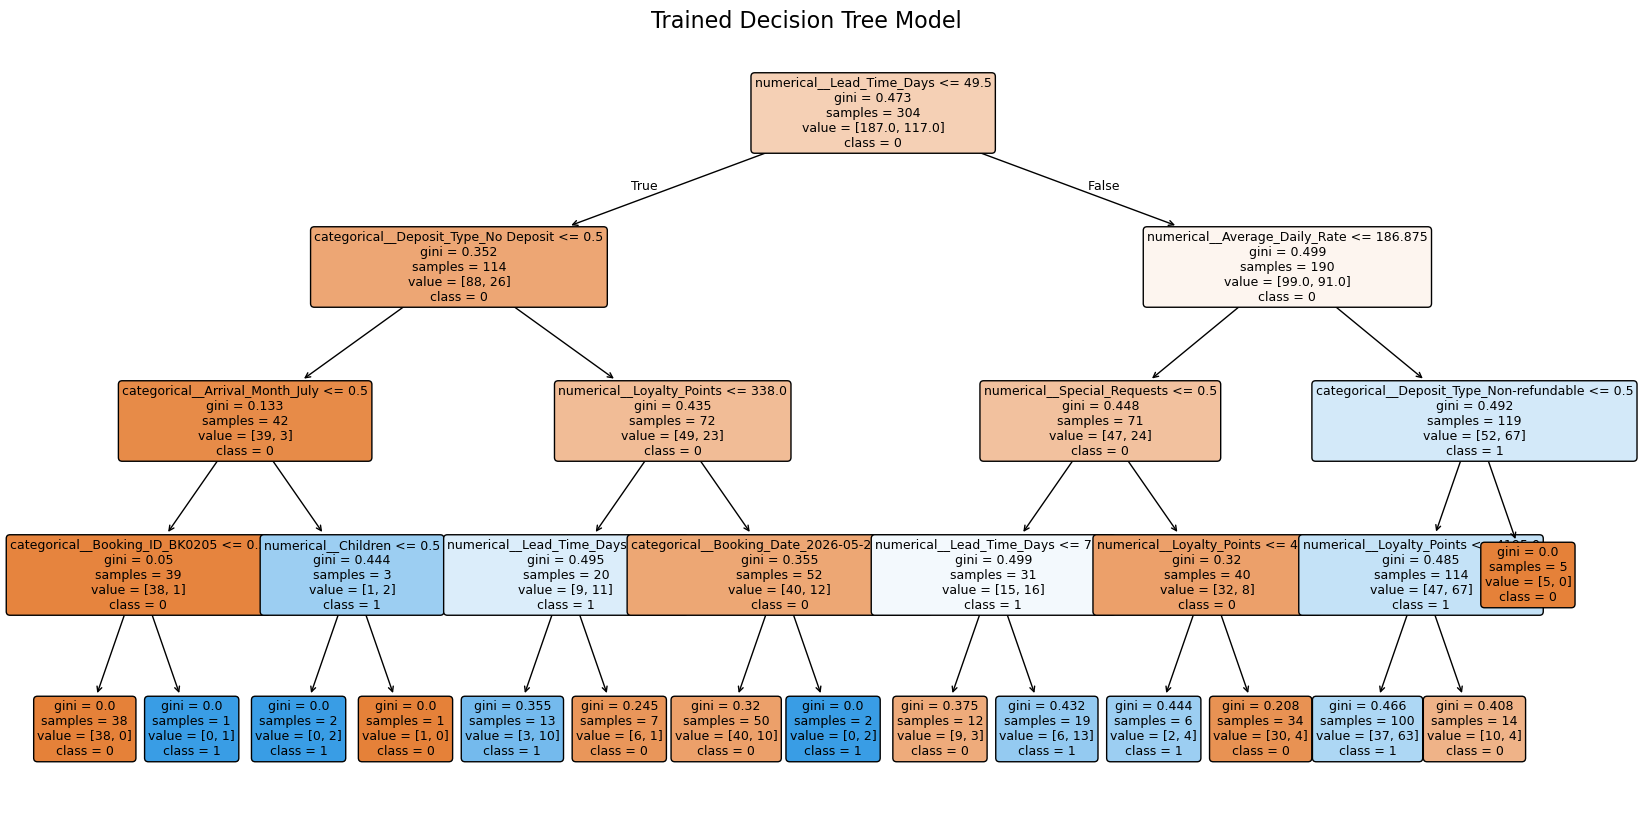

In [37]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=[str(c) for c in decision_tree_model.classes_],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Trained Decision Tree Model", fontsize=16)
plt.show()

In [39]:
# Get the depth of the trained Decision Tree
tree_depth = decision_tree_model.get_depth()
# Get the number of leaf nodes in the trained Decision Tree
tree_leaves = decision_tree_model.get_n_leaves()
# Print the depth of the tree
print("Decision Tree depth:", tree_depth)
# Print the number of leaf nodes
print("Number of leaf nodes:", tree_leaves)

Decision Tree depth: 4
Number of leaf nodes: 15


In [41]:
y_pred_dt = decision_tree_model.predict(X_test_processed)
# Print a message to confirm that predictions have been created
print("Decision Tree predictions have been created successfully.")

Decision Tree predictions have been created successfully.


In [43]:
# Create a DataFrame to compare actual and predicted values
dt_results = pd.DataFrame({
# Store the actual values from the testing set
"Actual": y_test.values,
# Store the predicted values from the Decision Tree model
"Predicted": y_pred_dt
})
# Print a title for the output
print("Actual vs Predicted Values")
# Print a separator line
print("-" * 50)
# Display the first ten actual and predicted values
display(dt_results.head(10))

Actual vs Predicted Values
--------------------------------------------------


,Actual,Predicted
0,0,0
1,0,0
2,0,1
3,0,0
4,0,0
5,0,1
6,1,0
7,0,1
8,0,1
9,0,0


In [45]:
# Import accuracy_score to calculate model accuracy
from sklearn.metrics import accuracy_score
# Calculate the accuracy of the Decision Tree model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)
# Print the Decision Tree testing accuracy
print("Decision Tree Test Accuracy:")
# Display the accuracy value
print(dt_test_accuracy)

Decision Tree Test Accuracy:
0.5526315789473685


In [47]:
# Predict the target values for the training data
y_train_pred_dt = decision_tree_model.predict(X_train_processed)
# Calculate the accuracy of the model on the training data
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
# Calculate the accuracy of the model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)
# Print the training accuracy
print("Decision Tree Training Accuracy:", dt_train_accuracy)
# Print the testing accuracy
print("Decision Tree Testing Accuracy:", dt_test_accuracy)

Decision Tree Training Accuracy: 0.7697368421052632
Decision Tree Testing Accuracy: 0.5526315789473685


In [49]:
# Create a small table to compare training and testing accuracy
dt_accuracy_table = pd.DataFrame({
# Store model evaluation type
"Evaluation Set": ["Training Set", "Testing Set"],
# Store accuracy values
"Accuracy": [dt_train_accuracy, dt_test_accuracy]
})
# Display the accuracy comparison table
display(dt_accuracy_table)

,Evaluation Set,Accuracy
0,Training Set,0.769737
1,Testing Set,0.552632


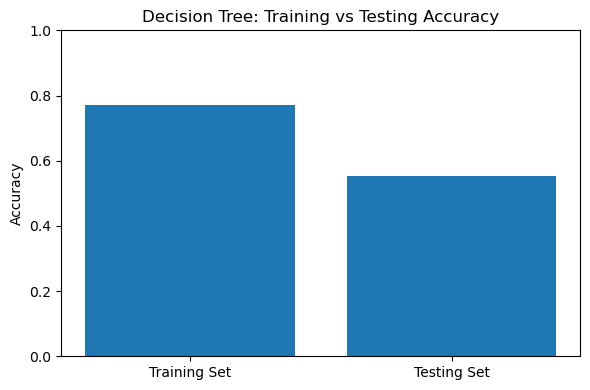

In [51]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt
# Create a figure for the accuracy comparison chart
plt.figure(figsize=(6, 4))
# Create a bar chart for training and testing accuracy
plt.bar(dt_accuracy_table["Evaluation Set"], dt_accuracy_table["Accuracy"])
# Add a title to the chart
plt.title("Decision Tree: Training vs Testing Accuracy")
# Add a label to the y-axis
plt.ylabel("Accuracy")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Adjust the layout
plt.tight_layout()
# Display the chart
plt.show()

In [53]:
# Count actual class values in the testing set
actual_counts = y_test.value_counts()
# Count predicted class values from the Decision Tree model
predicted_counts = pd.Series(y_pred_dt).value_counts()
# Create a comparison table for actual and predicted class counts
class_count_comparison = pd.DataFrame({
# Store actual class counts
"Actual": actual_counts,
# Store predicted class counts
"Predicted": predicted_counts
})
# Fill any missing values with zero
class_count_comparison = class_count_comparison.fillna(0)
# Display the comparison table
display(class_count_comparison)

,Actual,Predicted
0,57,35
1,19,41


<Figure size 700x400 with 0 Axes>

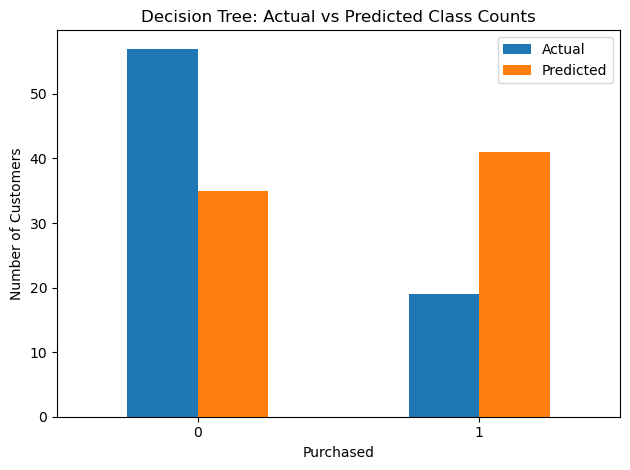

In [57]:
# Create a figure for actual vs predicted class counts
plt.figure(figsize=(7, 4))
# Create a bar chart for actual and predicted class counts
class_count_comparison.plot(kind="bar")
# Add a title to the chart
plt.title("Decision Tree: Actual vs Predicted Class Counts")
# Add a label to the x-axis
plt.xlabel("Purchased")
# Add a label to the y-axis
plt.ylabel("Number of Customers")
# Rotate x-axis labels
plt.xticks(rotation=0)
# Adjust the layout
plt.tight_layout()
# Display the chart
plt.show()

In [63]:
# Import confusion_matrix to calculate the confusion matrix
from sklearn.metrics import confusion_matrix
# Import ConfusionMatrixDisplay to visualize the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Import matplotlib for creating the figure
import matplotlib.pyplot as plt

In [71]:
# Define the class labels in a fixed order
class_labels = ["No", "Yes"]
# Calculate the confusion matrix for the Decision Tree model
cm_dt = confusion_matrix(y_test, y_pred_dt)
# Print a title for the output
print("Decision Tree Confusion Matrix")
# Print a separator line
print("-" * 50)
# Display the confusion matrix values
print(cm_dt)
# Create a DataFrame to show the confusion matrix in a readable table format
cm_dt_table = pd.DataFrame(
# Use the confusion matrix values
cm_dt,
# Set row labels as actual classes
index=["Actual No", "Actual Yes"],
# Set column labels as predicted classes
columns=["Predicted No", "Predicted Yes"]
)
# Display the confusion matrix table
display(cm_dt_table)

Decision Tree Confusion Matrix
--------------------------------------------------
[[29 28]
 [ 6 13]]


,Predicted No,Predicted Yes
Actual No,29,28
Actual Yes,6,13


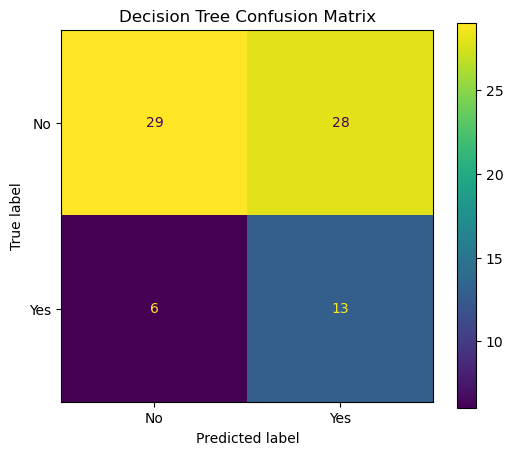

In [73]:
# Create a figure for the confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
# Create a confusion matrix display object
disp = ConfusionMatrixDisplay(
# Use the Decision Tree confusion matrix
confusion_matrix=cm_dt,
# Use class labels for display
display_labels=class_labels
)
# Plot the confusion matrix
disp.plot(ax=ax, values_format="d")
# Add a title to the figure
plt.title("Decision Tree Confusion Matrix")
# Display the figure
plt.show()

In [75]:
# Extract values from the confusion matrix
tn, fp, fn, tp = cm_dt.ravel()
# Print True Negative value
print("True Negative:", tn)
# Print False Positive value
print("False Positive:", fp)
# Print False Negative value
print("False Negative:", fn)
# Print True Positive value
print("True Positive:", tp)

True Negative: 29
False Positive: 28
False Negative: 6
True Positive: 13


In [77]:
confusion_explanation = pd.DataFrame({
    "Component": [
        "True Negative (Correct Not Cancelled)",
        "False Positive (Predicted Cancelled but actually Not Cancelled)",
        "False Negative (Predicted Not Cancelled but actually Cancelled)",
        "True Positive (Correct Cancelled)"
    ],
    "Meaning": [
        "Model correctly predicted booking will NOT be cancelled",
        "Model predicted cancellation but booking was actually not cancelled",
        "Model missed a real cancellation",
        "Model correctly predicted booking cancellation"
    ],
    "Value": [tn, fp, fn, tp]
})

confusion_explanation

,Component,Meaning,Value
0,True Negative (Correct Not Cancelled),Model correctly predicted booking will NOT be ...,29
1,False Positive (Predicted Cancelled but actual...,Model predicted cancellation but booking was a...,28
2,False Negative (Predicted Not Cancelled but ac...,Model missed a real cancellation,6
3,True Positive (Correct Cancelled),Model correctly predicted booking cancellation,13


In [79]:
# Import accuracy_score to calculate overall correct predictions
from sklearn.metrics import accuracy_score
# Import precision_score to calculate precision
from sklearn.metrics import precision_score
# Import recall_score to calculate recall
from sklearn.metrics import recall_score
# Import f1_score to calculate the F1-score
from sklearn.metrics import f1_score
# Import classification_report to show a full performance summary
from sklearn.metrics import classification_report

In [81]:
# Calculate the accuracy of the Decision Tree model
dt_accuracy = accuracy_score(y_test, y_pred_dt)

In [83]:
# Print the accuracy score
print("Decision Tree Accuracy:")
# Display the accuracy value
print(dt_accuracy)

Decision Tree Accuracy:
0.5526315789473685


In [87]:
dt_precision = precision_score(y_test, y_pred_dt,zero_division=0)
# Print the precision score
print("Decision Tree Precision:")
# Display the precision value
print(dt_precision)

Decision Tree Precision:
0.3170731707317073


In [89]:
# Calculate recall for the positive class, which is "Yes"
dt_recall = recall_score(y_test, y_pred_dt, zero_division=0)
# Print the recall score
print("Decision Tree Recall:")
# Display the recall value
print(dt_recall)

Decision Tree Recall:
0.6842105263157895


In [91]:
#Calculate F1-score for the positive class, which is "Yes"
dt_f1 = f1_score(y_test, y_pred_dt, zero_division=0)
# Print the F1-score
print("Decision Tree F1-Score:")
# Display the F1-score value
print(dt_f1)

Decision Tree F1-Score:
0.43333333333333335


In [93]:
# Create a DataFrame to summarize the Decision Tree evaluation metrics
dt_metrics_table = pd.DataFrame({# Store the metric names
"Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
# Store the metric values
"Score": [dt_accuracy, dt_precision, dt_recall, dt_f1]
})
# Display the metrics summary table
display(dt_metrics_table)

,Metric,Score
0,Accuracy,0.552632
1,Precision,0.317073
2,Recall,0.684211
3,F1-Score,0.433333


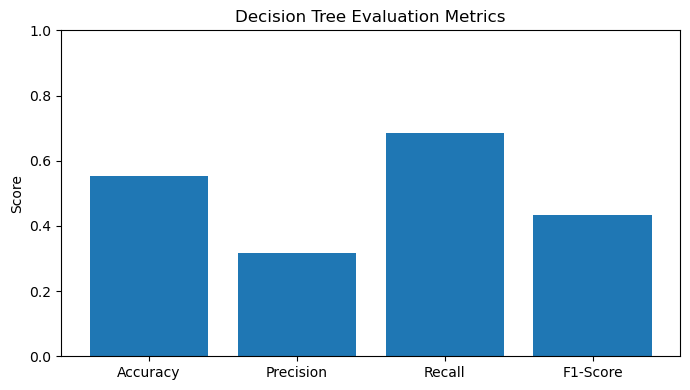

In [95]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt
# Create a figure for the evaluation metrics chart
plt.figure(figsize=(7, 4))
# Create a bar chart for the metrics
plt.bar(dt_metrics_table["Metric"], dt_metrics_table["Score"])
# Add a title to the chart
plt.title("Decision Tree Evaluation Metrics")
# Add a label to the y-axis
plt.ylabel("Score")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Adjust the layout so labels do not overlap
plt.tight_layout()
# Display the chart
plt.show()

In [97]:
# Print a title for the classification report
print("Decision Tree Classification Report")
# Print a separator line
print("-" * 50)
# Display the classification report for both classes
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.51      0.63        57
           1       0.32      0.68      0.43        19

    accuracy                           0.55        76
   macro avg       0.57      0.60      0.53        76
weighted avg       0.70      0.55      0.58        76



In [99]:
# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier
# Create a Decision Tree model without limiting max_depth
overfit_tree_model = DecisionTreeClassifier(
# Allow the tree to grow as much as possible
max_depth=None,
# Use a fixed random state to make the result reproducible
random_state=42
)
# Train the overfitted Decision Tree model using the processed training data
overfit_tree_model.fit(X_train_processed, y_train)
# Print a message to confirm that the model has been trained
print("Overfitted Decision Tree model has been trained.")

Overfitted Decision Tree model has been trained.


In [101]:
# Predict the target values for the training data using the overfitted tree
y_train_pred_overfit = overfit_tree_model.predict(X_train_processed)
# Predict the target values for the testing data using the overfitted tree
y_test_pred_overfit = overfit_tree_model.predict(X_test_processed)
# Calculate training accuracy for the overfitted tree
overfit_train_accuracy = accuracy_score(y_train, y_train_pred_overfit)
# Calculate testing accuracy for the overfitted tree
overfit_test_accuracy = accuracy_score(y_test, y_test_pred_overfit)
# Print the training accuracy
print("Overfitted Tree Training Accuracy:", overfit_train_accuracy)
# Print the testing accuracy
print("Overfitted Tree Testing Accuracy:", overfit_test_accuracy)

Overfitted Tree Training Accuracy: 1.0
Overfitted Tree Testing Accuracy: 0.5789473684210527


In [103]:
y_train_pred_controlled = decision_tree_model.predict(X_train_processed)
# Predict the target values for the testing data using the controlled Decision␣Tree
y_test_pred_controlled = decision_tree_model.predict(X_test_processed)
# Calculate training accuracy for the controlled Decision Tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)
# Calculate testing accuracy for the controlled Decision Tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)
# Create a comparison table for both models
overfitting_comparison = pd.DataFrame({
# Store the model names
"Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
# Store the training accuracy values
"Training Accuracy": [controlled_train_accuracy, overfit_train_accuracy],
# Store the testing accuracy values
"Testing Accuracy": [controlled_test_accuracy, overfit_test_accuracy]
})
# Display the comparison table
display(overfitting_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Controlled Decision Tree,0.769737,0.552632
1,Overfitted Decision Tree,1.000000,0.578947


<Figure size 800x500 with 0 Axes>

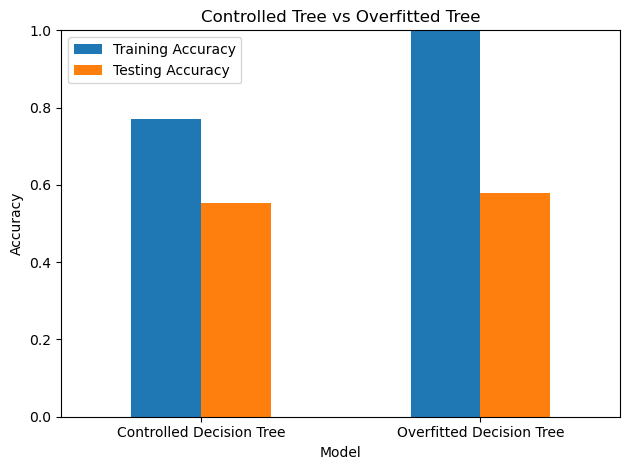

In [105]:
# Set the model column as the index for better plotting
overfitting_comparison_plot = overfitting_comparison.set_index("Model")
# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))
# Create a bar chart for training and testing accuracy
overfitting_comparison_plot.plot(kind="bar")
# Add a title to the chart
plt.title("Controlled Tree vs Overfitted Tree")
# Add a label to the y-axis
plt.ylabel("Accuracy")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Rotate x-axis labels for better readability
plt.xticks(rotation=0)
# Adjust layout to avoid overlap
plt.tight_layout()
# Display the chart
plt.show()